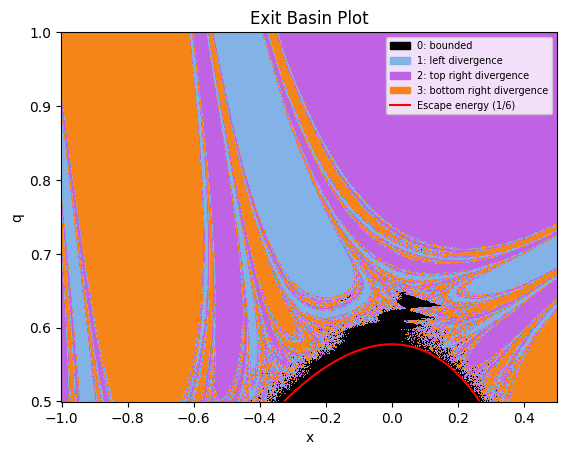

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

def plot_exit_basin_from_file(filename='exit_basin_data.npz'):
    # 1. Load the pre-computed data
    data = np.load(filename)
    X = data['X']
    Q = data['Q']
    C = data['C']
    Z_simple = data['Z']  # You saved Z_simple under the key 'Z' in your np.savez call

    # 2. Set up the exact same colormap and labels
    cmap = ListedColormap([
        "black",   
        "#82B2E6",
        "#BF62E3", 
        "#F58518"
    ])
    labels = [
        "0: bounded",
        "1: left divergence",
        "2: top right divergence",
        "3: bottom right divergence"
    ]

    # 3. Create legend patches for the categorized regions
    legend_handles = [
        mpatches.Patch(color=cmap(i), label=labels[i])
        for i in range(4)
    ]

    # 4. Create a custom line handle for the contour and append it to the legend
    contour_handle = Line2D([0], [0], color='red', lw=1.5, label='Escape energy (1/6)')
    legend_handles.append(contour_handle)

    # 5. Build the plot
    plt.figure()
    plt.pcolormesh(X, Q, C, cmap=cmap, shading='auto')

    # Plot escape energy contour
    plt.contour(X, Q, Z_simple, levels=[1/6], colors='red')

    plt.xlabel("x")
    plt.ylabel("q")
    plt.title("Exit Basin Plot")
    
    # Pass the updated handles list into the legend
    plt.legend(handles=legend_handles, loc="upper right", prop={'size': 7})

    plt.show()

# Run the function using your saved file
plot_exit_basin_from_file('exit_basin_data.npz')

In [11]:
def find_isolated_pixel(filename='exit_basin_data.npz'):
    # 1. Load the pre-computed arrays
    data = np.load(filename)
    X = data['X']
    Q = data['Q']
    C = data['C']

    # 2. Create a boolean mask with all your conditions
    # This creates an array of True/False values matching the shape of your grid
    target_mask = (C == 0) & (X > 0) & (X < 0.03) & (Q > 0.62) & (Q < 0.63)

    # 3. Find the exact row and column indices where the mask is True
    indices = np.where(target_mask)

    # 4. Check if we found anything
    num_matches = len(indices[0])
    if num_matches == 0:
        print("No pixels found matching the criteria. Try widening the search area.")
        return None

    print(f"Success! Found {num_matches} pixel(s) matching the criteria:\n")

    # 5. Extract and display the exact initial conditions for each match
    for i in range(num_matches):
        row = indices[0][i]
        col = indices[1][i]
        
        x_val = X[row, col]
        q_val = Q[row, col]
        
        print(f"--- Match {i+1} ---")
        print(f"Array Index: [{row}, {col}]")
        print(f"Exact Coordinates: x = {x_val}, q = {q_val}")
        print(f"Initial Condition for Trajectory: u0 = [{x_val}, 0, 0, {q_val}]\n")

    # Return the first found point so you can pass it to your trajectory solver
    first_x = X[indices[0][0], indices[1][0]]
    first_q = Q[indices[0][0], indices[1][0]]
    
    return [first_x, 0, 0, first_q]

# Run the search
target_u0 = find_isolated_pixel()

# You can now pass target_u0 directly into your solve_clover or trajectory plotting function!
# if target_u0:
#     show_trajectory_fancy_3(target_u0, title="Trajectory of the Isolated

Success! Found 47 pixel(s) matching the criteria:

--- Match 1 ---
Array Index: [120, 333]
Exact Coordinates: x = 0.0010020040080160886, q = 0.6202404809619239
Initial Condition for Trajectory: u0 = [0.0010020040080160886, 0, 0, 0.6202404809619239]

--- Match 2 ---
Array Index: [120, 334]
Exact Coordinates: x = 0.004008016032064132, q = 0.6202404809619239
Initial Condition for Trajectory: u0 = [0.004008016032064132, 0, 0, 0.6202404809619239]

--- Match 3 ---
Array Index: [120, 335]
Exact Coordinates: x = 0.007014028056112176, q = 0.6202404809619239
Initial Condition for Trajectory: u0 = [0.007014028056112176, 0, 0, 0.6202404809619239]

--- Match 4 ---
Array Index: [120, 336]
Exact Coordinates: x = 0.01002004008016022, q = 0.6202404809619239
Initial Condition for Trajectory: u0 = [0.01002004008016022, 0, 0, 0.6202404809619239]

--- Match 5 ---
Array Index: [120, 337]
Exact Coordinates: x = 0.013026052104208485, q = 0.6202404809619239
Initial Condition for Trajectory: u0 = [0.01302605210